In [14]:
from utils import * # includes some global functions/variables
from pdediff.sde import VPSDE

# Global Variables

### Specify the global variables in utils.py

- A() - observation operator 
- float T - final diffusion time
- float alpha - noise added at 1st diffusion step
- int diff_steps - number of diffusion steps
- int ts[] - array of indecies used for indexing the diffusion process $t$
- float sigmas2_total[]- total noise added at each index $\sigma^2(t)$
- float del_sigmas2[] - variance of noise increment added at each diffusion step $\sigma^2(t) -\sigma^2(t-1)$
- float del_sigmas[] - std of noise added at each diffusion step $\sqrt{\sigma^2(t) -\sigma^2(t-1)}$
- float sigma_y - observation noise
- int dims - dimentionality of the data



In [2]:
n = 1000 # trials
dims = 1 # dimensionality of data (only works for 1D rn)

xt = torch.zeros(diff_steps, n, dims)
xt_bwd = torch.zeros_like(xt)
xt[0] = sample_p0(n).reshape((n, dims))
for t in range(1, diff_steps): # noising process
    xt[t] = xt[t-1] + del_sigmas[t-1]*torch.randn(n, dims)

#reverse the process
xt_bwd[-1] = xt[-1].clone().detach()
for t in range(diff_steps-1, 0, -1):
    score = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2[t-1] * score + del_sigmas[t-1] *torch.randn(n, dims)

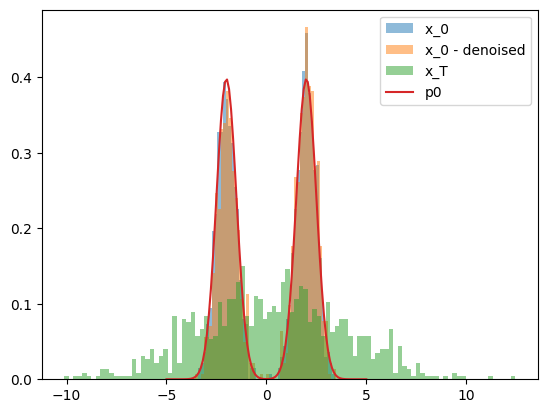

In [3]:
# plot histogram

_ = plt.hist(xt[0].detach().numpy(), bins=50, alpha=0.5, label='x_0 ', density=True)
_ = plt.hist(xt_bwd[0].detach().numpy(), bins=50, alpha=0.5, label='x_0 - denoised', density=True)
_ = plt.hist(xt[-1].detach().numpy(), bins=100, alpha=0.5, label='x_T', density=True)
x = torch.linspace(-5, 5, 100).reshape(-1, 1)
plt.plot(x.detach().numpy(), pt(x, 1).detach().numpy(), label='p0')
plt.legend()

# MC Guidance Estimates

In [4]:
placeholder_x0 = 0.0
y =  torch.ones_like(xt[0]) * A(tensor([placeholder_x0])) # A(xt[0]) + sigma_y*torch.randn_like(xt[0]) #
print(sigma_y, A(tensor([placeholder_x0])), (1-A(tensor([placeholder_x0]))**2)**-1)

tensor([[0.0100]]) tensor([0.]) tensor([1.])


In [5]:
# Will likely fail if observation noise is too low

guidances = torch.zeros_like(xt) # loging
scores = torch.zeros_like(xt) # loging
xt_bwd = torch.zeros_like(xt) # loging
xt_bwd[-1] = xt[-1].clone().detach().requires_grad_(True) #xt[time, samples, dims]
for t in tqdm(range(diff_steps-1, 0, -1)):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    guidance = get_guidance(xt_bwd[t], y, t, 1000)[0]
    guidances[t] = guidance
    scores[t] = sc
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t] * (sc + guidance) + torch.randn_like(xt_bwd[t]) * del_sigmas[t-1]

100%|██████████| 49/49 [00:03<00:00, 14.19it/s]


tensor(0.2164, grad_fn=<MeanBackward0>) tensor(50.7636, grad_fn=<StdBackward0>)


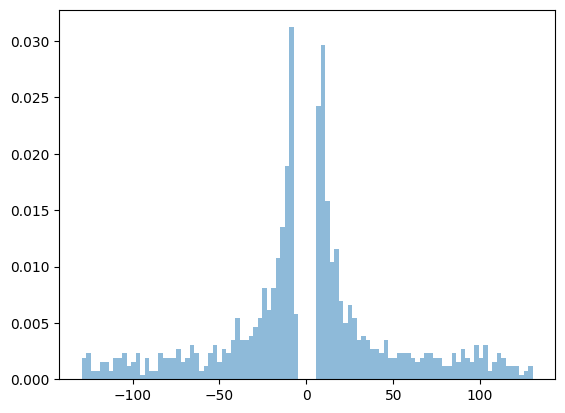

In [6]:
_ = plt.hist((xt_bwd[0]).detach().numpy(), bins=100, alpha=0.5, label='bwd', density=True)
print(xt_bwd[0].mean(), xt_bwd[0].std())

# Importance sampling Guidance Estimate



In [7]:
placeholder_x0 = tensor([0.0]).requires_grad_(True)
placeholder_y = A(placeholder_x0)
y =  torch.ones_like(xt[0]) * A(placeholder_x0) # A(xt[0]) + sigma_y*torch.randn_like(xt[0]) #
y_temp = A(placeholder_x0).requires_grad_(True)
partial_A = torch.autograd.grad(y_temp, placeholder_x0, torch.ones_like(placeholder_x0), create_graph=True)[0]
print(sigma_y, y[0].item(), A(placeholder_x0).item(), partial_A**-1)

guidances = torch.zeros_like(xt) # logging
scores = torch.zeros_like(xt) # logging
xt_bwd = torch.zeros_like(xt) # logging
xt_bwd[-1] = xt[-1].clone().detach().requires_grad_(True) #xt[time, samples, dims]
for t in tqdm(range(diff_steps-1, 0, -1)):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    guidance = get_guidance_IS(y, xt_bwd[t].detach().requires_grad_(True), t, 1000)[0]
    guidances[t] = guidance
    scores[t] = sc
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t] * (sc + guidance) + torch.randn_like(xt_bwd[t]) * del_sigmas[t-1]

tensor([[0.0100]]) 0.0 0.0 tensor([1.], grad_fn=<PowBackward0>)


100%|██████████| 49/49 [00:23<00:00,  2.11it/s]


estimated mean and variance tensor(-7.2975e-10, grad_fn=<MulBackward0>) tensor(0.0100, grad_fn=<SqrtBackward0>)


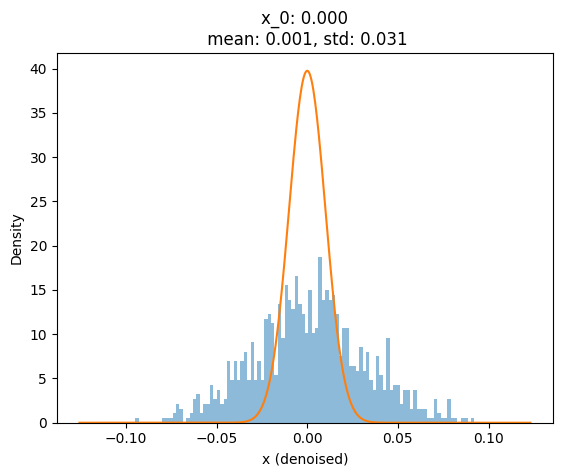

In [10]:
_ = plt.hist((xt_bwd[0]).detach().numpy(), bins=100, alpha=0.5, label='bwd', density=True)
# _ = plt.hist(y.detach().numpy(), bins=100, alpha=0.5, label='y', density=True)
mean_sampled = xt_bwd[0].mean()
std_sampled = xt_bwd[0].std()

# estimate the posterior distribution of x_0|y
x = torch.linspace(xt_bwd[0].min() - std_sampled, xt_bwd[0].max()+std_sampled, 500).reshape(-1, 1)
dx = (x[1] - x[0]).item()
log_p0_x = log_pt(x, 0)
log_py_x = log_p_y_given_x(placeholder_y, x)

log_px_y = log_py_x + log_p0_x
px_y = torch.exp(log_px_y)
px_y = px_y / (px_y.sum() * dx)
_ = plt.plot(x.detach().numpy(), px_y.detach().numpy(), label='true posterior')
plt.title(r'$p(x|y = A($' + f'{placeholder_x0.item()}))')
mean_est = (px_y * x.squeeze()).sum() * dx
std_est = torch.sqrt((px_y * (x.squeeze() - mean_est)**2).sum() * dx)
print('estimated mean and variance', mean_est, std_est)


_ = plt.title(f'x_0: {placeholder_x0.item():.3f}\n mean: {mean_sampled.item():.3f}, std: {std_sampled.item():.3f}')
_ = plt.ylabel('Density')
_ = plt.xlabel('x (denoised)')

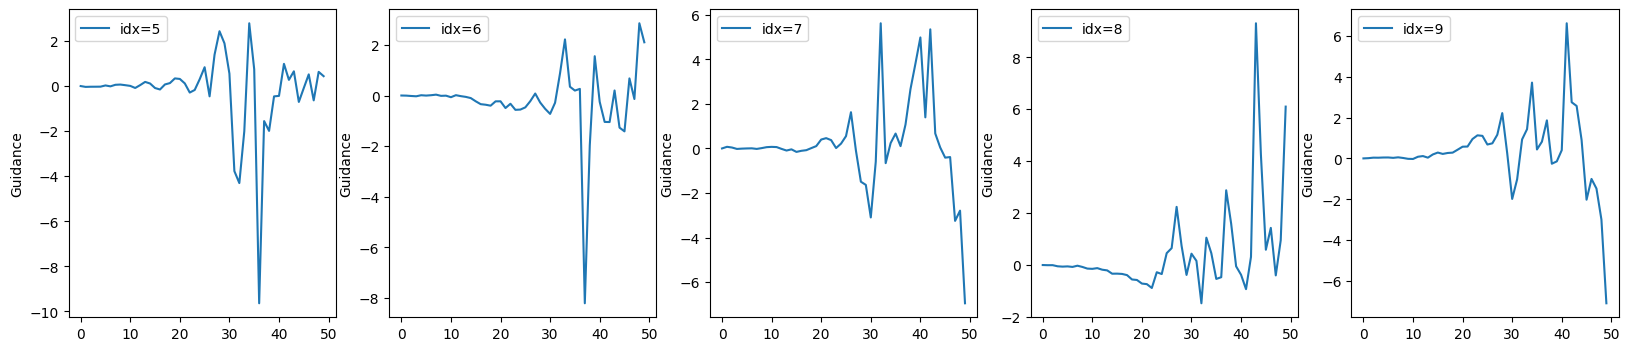

In [11]:
top_5_indices = torch.topk(guidances.abs().flatten(), 5).indices
top_5_locations = torch.unravel_index(top_5_indices, guidances.shape)
idx = top_5_locations[1]

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in zip([5,6,7,8,9], axs):
    ax.plot(sigmas2_total[1:] * guidances[:, i, 0].detach().numpy(), label=f'idx={i}') # sigmas2_total[1:] * guidances[:, i, 0]
    ax.set_ylabel('Guidance')
    ax.legend()